# pneumonia detection using CNN

# 1. Install Required Libraries

In [ ]:
 !pip install tensorflow keras matplotlib numpy scikit-learn

# importing libraries

In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Download Dataset via KaggleHub

In [ ]:
import kagglehub
import shutil
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Copy to working directory
DESTINATION = Path("chest-xray-pneumonia_dataset")
DESTINATION.mkdir(parents=True, exist_ok=True)
shutil.copytree(path, str(DESTINATION), dirs_exist_ok=True)

print("Dataset saved to:", DESTINATION)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset saved to: chest-xray-pneumonia_dataset


# Set Dataset Paths

In [ ]:
dataset_path = path + "/chest_xray"

train_dir = dataset_path + "/train"
val_dir = dataset_path + "/val"
test_dir = dataset_path + "/test"

print(train_dir)
print(val_dir)
print(test_dir)

/kaggle/input/chest-xray-pneumonia/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/test


In [ ]:
print("Train:", train_data.class_indices)
print("Validation:", val_data.class_indices)
print("Test:", test_data.class_indices)

Train: {'NORMAL': 0, 'PNEUMONIA': 1}
Validation: {'NORMAL': 0, 'PNEUMONIA': 1}
Test: {'NORMAL': 0, 'PNEUMONIA': 1}


#  Data Augmentation and Data Preprocessing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,

    shear_range=0.2,
    zoom_range=0.2,

    horizontal_flip=True
)


val_datagen = ImageDataGenerator(
    rescale=1./255
)

# Load Dataset

In [ ]:
train_data = train_datagen.flow_from_directory(
    "/content/chest-xray-pneumonia_dataset/chest_xray/train",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary"
)


val_data = val_datagen.flow_from_directory(
    "/content/chest-xray-pneumonia_dataset/chest_xray/val",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary"
)


test_data = val_datagen.flow_from_directory(
    "/content/chest-xray-pneumonia_dataset/chest_xray/test",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# Build CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout


model = Sequential()


model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

model.add(MaxPooling2D())


model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D())


model.add(Flatten())


model.add(Dropout(0.5))


model.add(Dense(
    128,
    activation='relu'
))


model.add(Dropout(0.5))


model.add(Dense(
    1,
    activation='sigmoid'
))

# Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 70s 399ms/step - accuracy: 0.7550 - loss: 0.5328 - val_accuracy: 0.5625 - val_loss: 0.9305
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 400ms/step - accuracy: 0.8299 - loss: 0.3664 - val_accuracy: 0.6250 - val_loss: 1.0919
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 404ms/step - accuracy: 0.8409 - loss: 0.3407 - val_accuracy: 0.7500 - val_loss: 0.6095
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 409ms/step - accuracy: 0.8564 - loss: 0.3184 - val_accuracy: 0.6875 - val_loss: 0.6658
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 396ms/step - accuracy: 0.8685 - loss: 0.2995 - val_accuracy: 0.8125 - val_loss: 0.6173
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 397ms/step - accuracy: 0.8783 - loss: 0.2876 - val_accuracy: 0.8125 - val_loss: 0.4655
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 397ms/step - accuracy: 0.8832 - loss: 0.2771 - val_accuracy: 0.8125 - val_loss: 0.7093
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 396ms/step - accuracy: 0.8817 - loss: 0

# check my model is overfit or not

In [ ]:
# Final training accuracy
train_accuracy = history.history['accuracy'][-1]

# Final validation accuracy
val_accuracy = history.history['val_accuracy'][-1]


print("Training Accuracy:", train_accuracy * 100)
print("Validation Accuracy:", val_accuracy * 100)

Training Accuracy: 89.9923324584961
Validation Accuracy: 81.25


# Evaluate Model

In [ ]:


loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy * 100, "%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - accuracy: 0.8862 - loss: 0.3058
Test Loss: 0.30584317445755005
Test Accuracy: 88.62179517745972 %


# Classification Report

In [ ]:
from sklearn.metrics import classification_report


# Prediction on test data

pred = model.predict(test_data)


# Convert probabilities to classes

y_pred = (pred > 0.5).astype(int).reshape(-1)



# Classification report

print(
    classification_report(
        test_data.classes,
        y_pred,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step
              precision    recall  f1-score   support

      NORMAL       0.88      0.80      0.84       234
   PNEUMONIA       0.89      0.94      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.88       624
weighted avg       0.89      0.89      0.89       624



# Confusion Matrix

In [ ]:
cm = confusion_matrix(
    test_data.classes,
    y_pred
)

print(cm)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Writing confusion


#  Accuracy and Loss Graphs

In [ ]:
import matplotlib.pyplot as plt


# Accuracy graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend(["Training Accuracy","Validation Accuracy"])

plt.title("Training vs Validation Accuracy")

plt.show()



# Loss graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(["Training Loss","Validation Loss"])

plt.title("Training vs Validation Loss")

plt.show()

Writing accuracy.graphs


# Save Model

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("pneumonia_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


# Predict New X-Ray

In [ ]:
print(train_data.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Raw Prediction: 0.9750557


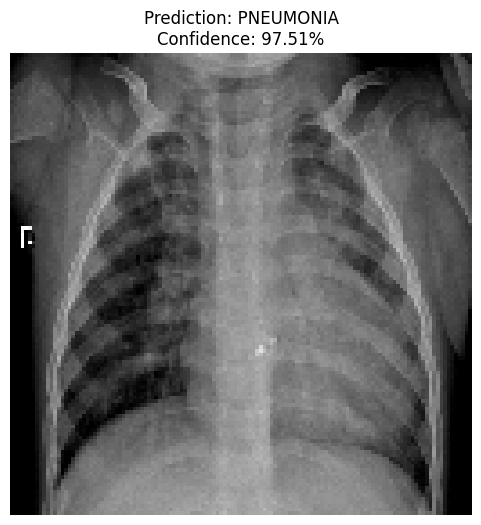

Prediction: PNEUMONIA
Confidence: 97.51%


In [ ]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np


img_path = "/content/chest-xray-pneumonia_dataset/chest_xray/train/PNEUMONIA/person1002_bacteria_2933.jpeg"


# Load image
img = image.load_img(
    img_path,
    target_size=(128,128)
)


# Convert to array
img_array = image.img_to_array(img)


# Normalize
img_array = img_array / 255.0


# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)



# Prediction
prediction = model.predict(img_array)


confidence = prediction[0][0]


print("Raw Prediction:", confidence)



# Correct class mapping
if confidence >= 0.5:

    result = "PNEUMONIA"
    score = confidence

else:

    result = "NORMAL"
    score = 1 - confidence



# Show image

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(
    f"Prediction: {result}\nConfidence: {score*100:.2f}%"
)

plt.axis("off")

plt.show()


print("Prediction:", result)
print("Confidence:", f"{score*100:.2f}%")